## Cleaning the dataset

In [ ]:
import pandas as pd

# 1. Cleaning tournaments (Macro context)
df_oldTournaments= pd.read_csv('../data/raw-oldWc/tournaments.csv')

titulares= ['year', 'winner', 'host_country', 'count_teams'] #we save what we consider are the important variables 

df_oldTournaments_CLEAN= df_oldTournaments[titulares]

df_oldTournaments_CLEAN.to_csv('../data/processed/tournaments_limpio.csv', index=False)

# 2. Cleaning matches (Predictive importance)
df_oldMatches= pd.read_csv('../data/raw-oldWc/matches.csv')

titulares_matches = [
    'year', 
    'stage_name', 
    'home_team_name', 
    'away_team_name', 
    'home_team_score', 
    'away_team_score', 
    'result'
]

df_oldMatches_CLEAN= df_oldMatches[titulares_matches]

df_oldMatches_CLEAN.to_csv('../data/processed/matches_limpio.csv', index=False)


## Feature Enginnering

##### Data leakage : "Occurs when information from outside the training dataset is used to train or evaluate a model" 
##### With the intention is to avoid target leakage (it happens when features that will not be available at the time of prediction are included in the training data), we will use feature enginnering, meaning, procesing the data in inputs that our implementation will learn from. In simple terms, we won't spoil information.

In [30]:
#we will calculate the average goals and matches played for each country, these are the features our model will evaluate to reach our target
# (determinate who would will the WC)

average_goals = {}
played_matches = {}
oldMatch_awayTeam=[]
oldMatch_homeTeam=[]

for index, row in df_oldMatches_CLEAN.iterrows():
    homeTeam= row['home_team_name']
    awayTeam= row['away_team_name']
    
    if homeTeam in played_matches and played_matches[homeTeam]>0:
        #in this case we will calculate the average
        local_average= average_goals[homeTeam] / played_matches[homeTeam]
    else:
        local_average=0.0
        
    oldMatch_homeTeam.append(local_average)
    
    if awayTeam in played_matches and played_matches[awayTeam]>0:
        
        away_average= average_goals[awayTeam]/ played_matches[awayTeam]
    else:
        away_average=0.0
    
    oldMatch_awayTeam.append(away_average)
    
    new_goals_awayTeam = row['away_team_score']
    new_goals_homeTeam = row['home_team_score']
    
    if homeTeam not in average_goals:
        average_goals[homeTeam] = 0
        played_matches[homeTeam] = 0
        
    if awayTeam not in average_goals:
        average_goals[awayTeam] = 0
        played_matches[awayTeam] = 0

    average_goals[homeTeam] += new_goals_homeTeam
    played_matches[homeTeam] += 1
    
    average_goals[awayTeam] += new_goals_awayTeam
    played_matches[awayTeam] += 1
    
df_oldMatches_CLEAN['home_team_avg_goals'] = oldMatch_homeTeam
df_oldMatches_CLEAN['away_team_avg_goals'] = oldMatch_awayTeam

df_oldMatches_CLEAN.to_csv('../data/processed/matches_con_features.csv', index=False)


## Correlation Analysis

##### It  will measure the statistical relationships between variables in a dataset. Ranging from -1 to 1, it will evaluates how changes in one variable correspond to changes in another. Because we have so much information, in this way we will identify features that have a strong correlation with our target variable, this will ensure our model learns from the most relevant data.


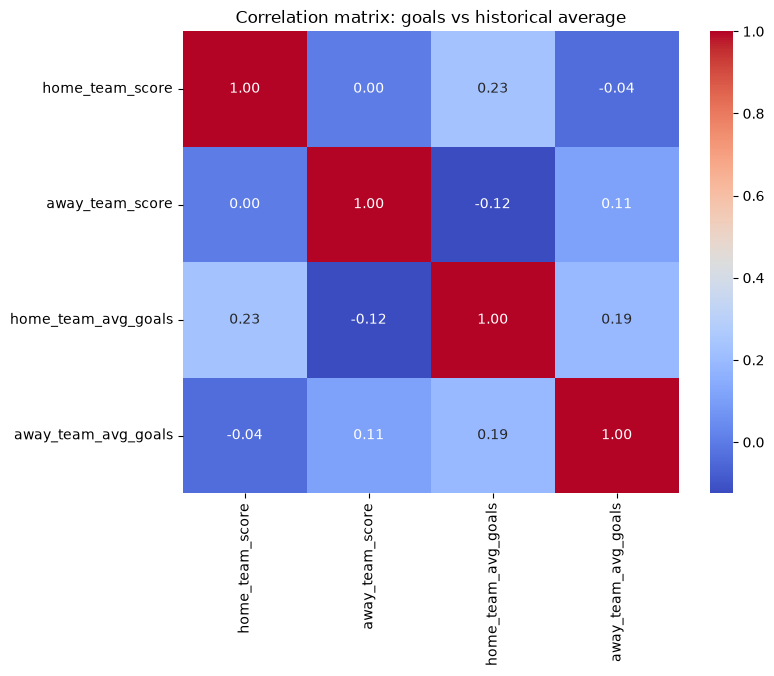

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

num_rows = df_oldMatches_CLEAN[['home_team_score', 'away_team_score', 'home_team_avg_goals', 'away_team_avg_goals']]

correlation_matrix = num_rows.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix: goals vs historical average')
plt.show()


    -> home_team_score vs home_team_avg_goals (0.23)

Positive correlation, it means that if a local teal has a good historical average, its probable that will score a goal in the match.

    -> away_team_score vs away_team_avg_goals (0.11)
Also a positive correlation. It's weaker than the home team one (which means sense because being the away team it's "harder"), but overall useful information

    ->  home_team_score vs away_team_score (0.0)
Even though its correlation is 0, it would be a mistake not use them in our model. Correlation matrix is a useful tool to use as a first filter, because it only measures linear relations. 

In football, unilateral blowouts and high-scoring balanced matches mix together, canceling each other out and resulting in a flat 0.0 line mathematically.

Furthermore, we must keep these variables for two main reasons:

* Feature Synergy: Traditional statistics evaluate variables in isolation. However, a variable that seems useless on its own can become highly predictive when combined with the context of other variables (like the tournament stage or the historical averages).

* Machine Learning Capabilities: Advanced algorithms (like Random Forest or XGBoost) do not look for simple straight lines. They have the capacity to understand chaos and create complex decision trees. Our AI model will be able to discover the non-linear patterns and hidden interactions that the traditional correlation matrix cannot see.
